In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from scipy.interpolate import interp1d

# Irradiance Trace Visualization

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Tue Dec 29 12:26:39 2020', '__version__': '1.0', '__globals__': [], 'Gmonth': array([[0.00000000e+00, 0.00000000e+00],
       [9.00000000e+02, 6.76852745e+01],
       [1.80000000e+03, 7.77214440e+01],
       ...,
       [7.73460000e+06, 0.00000000e+00],
       [7.73550000e+06, 0.00000000e+00],
       [7.73640000e+06, 0.00000000e+00]], shape=(4770, 2))}
Shape: (4770, 2)
Timestamp:
[0.0000e+00 9.0000e+02 1.8000e+03 ... 7.7346e+06 7.7355e+06 7.7364e+06]
Irradiance:
[ 0.         67.68527452 77.72144401 ...  0.          0.
  0.        ]


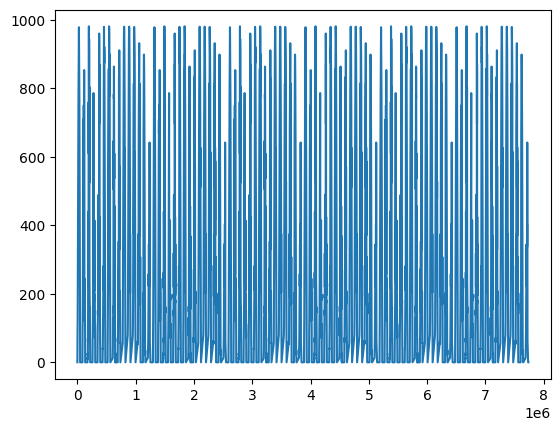

In [21]:
# Load the .mat file
mat_file = scipy.io.loadmat('gmonths.mat')

# Display the contents of the .mat file
print(mat_file)  # -> dict
print(f"Shape: {mat_file['Gmonth'].shape}")
timestamp = mat_file['Gmonth'][:, 0]  # [s]
irradiance = mat_file['Gmonth'][:, 1]  # [W/m^2]
print(f"Timestamp:\n{timestamp}")
print(f"Irradiance:\n{irradiance}")

# Plot
fig, ax = plt.subplots()
ax.plot(timestamp, irradiance)

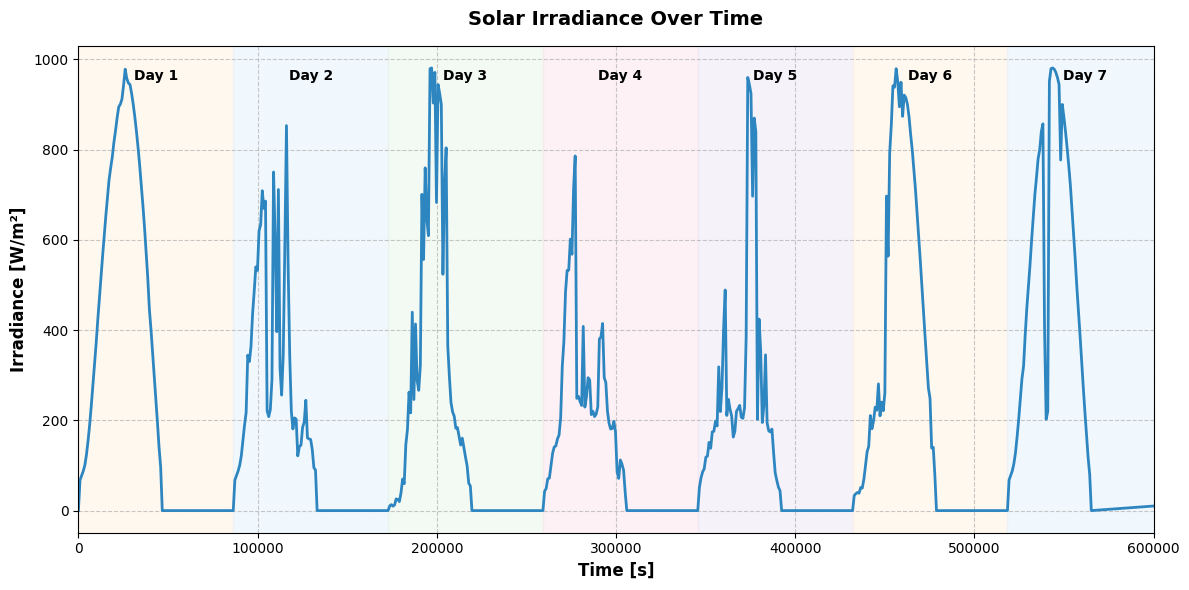

In [22]:
# Display the first six days
BEGIN, END = 0, int(6 * 86_400 / 900)
fig, ax = plt.subplots(figsize=(12, 6))

# Plot main data
ax.plot(timestamp[BEGIN:END], irradiance[BEGIN:END], 
        label='Irradiance', 
        color='#2E86C1', 
        linewidth=2)

# Add colored backgrounds and labels for each day
colors = ['#FFF3E0', '#E3F2FD', '#E8F5E9', '#FCE4EC', '#EDE7F6']
seconds_per_day = 86_400

for day in range(((END * 900) // seconds_per_day) + 1):
    day_start = day * seconds_per_day
    day_end = (day + 1) * seconds_per_day
    
    # Add colored background
    ax.axvspan(day_start, day_end, 
               color=colors[day % len(colors)], 
               alpha=0.5,
               label=f'Day {day+1}')
    
    # Add day label
    ax.text((day_start + day_end)/2, ax.get_ylim()[1]*0.95,
            f'Day {day+1}',
            horizontalalignment='center',
            verticalalignment='top',
            fontsize=10,
            fontweight='bold')

# Customize appearance
ax.set_xlabel('Time [s]', fontsize=12, fontweight='bold')
ax.set_ylabel('Irradiance [W/m²]', fontsize=12, fontweight='bold')
ax.set_title('Solar Irradiance Over Time', fontsize=14, pad=15, fontweight='bold')

# Add grid and legend
ax.grid(True, which='major', linestyle='--', alpha=0.7)

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_xlim(0, 600_000)

plt.tight_layout()
plt.show()

# PV Panel Datasheet Digitalization

![](datasheet/PVcell/datasheet.bmp)

The [plotdigitizer](https://plotdigitizer.com/app) is easy to use and suggested. Any other software can be used to digitize the datasheet.

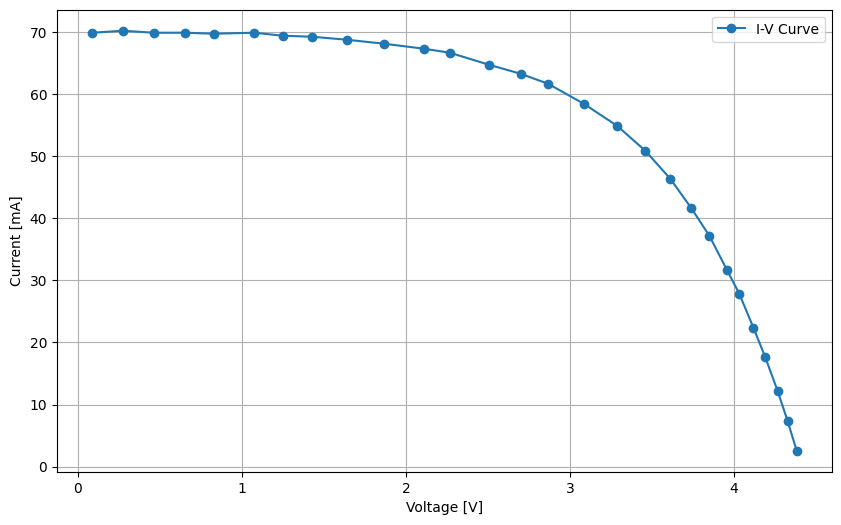

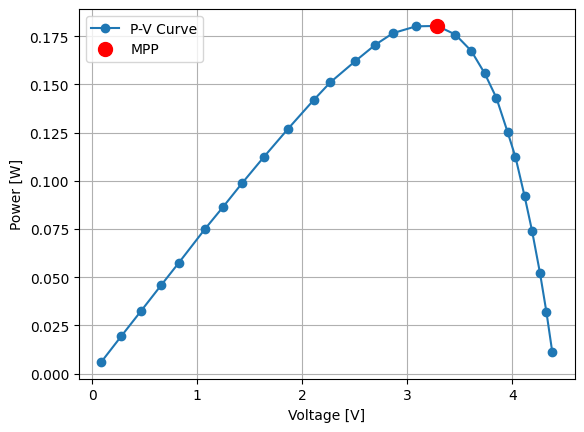

Curve 250 W/m^2. V: 3.0020280569805857[V]; I: 13.19919619647824[mA]; P: 0.039624357311419105 [W]
Curve 500 W/m^2. V: 3.0020280569805857[V]; I: 28.32997698824206[mA]; P: 0.085047385772317 [W]
Curve 750 W/m^2. V: 3.138945116336653[V]; I: 41.85110599738712[mA]; P: 0.1313683247837859 [W]
Curve 1000 W/m^2. V: 3.286004008140084[V]; I: 54.88933271735312[mA]; P: 0.18036656731335698 [W]


In [23]:
# Plot only trace_1000.txt
# Print all of the info
# Extract digitalized curve points
data = np.loadtxt('datasheet/PVcell/trace_1000.txt', delimiter=',', skiprows=1)

# Extract columns
voltage = data[:, 0]
current = data[:, 1]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(voltage, current, 'o-', label='I-V Curve')
plt.xlabel('Voltage [V]')
plt.ylabel('Current [mA]')
plt.legend()
plt.grid(True)
plt.show()

# Extract MPP for each curve
current_A = current / 1000  
power = np.multiply(voltage, current_A)

mpp_index = np.argmax(power)

V_mpp = voltage[mpp_index]
P_mpp = power[mpp_index]

# Plot P-V curve
plt.plot(voltage, power, 'o-', label='P-V Curve')

# Plot MPP on top of it
plt.plot(V_mpp, P_mpp, 'ro', markersize=10, label='MPP')

plt.xlabel('Voltage [V]')
plt.ylabel('Power [W]')
plt.legend()
plt.grid(True)

plt.show()

filenames = ['datasheet/PVcell/trace_250.txt', 'datasheet/PVcell/trace_500.txt', 'datasheet/PVcell/trace_750.txt', 'datasheet/PVcell/trace_1000.txt']
for i in range (4):
    data = np.loadtxt(filenames[i], delimiter=',', skiprows=1)

    # Extract columns
    voltage = data[:, 0]
    current = data[:, 1]

    # Extract MPP for each curve
    current_A = current / 1000  
    power = np.multiply(voltage, current_A)

    mpp_index = np.argmax(power)

    V_mpp = voltage[mpp_index]
    I_mpp = current[mpp_index]
    P_mpp = power[mpp_index]
    print(f"Curve {(i+1)*250} W/m^2. V: {V_mpp}[V]; I: {I_mpp}[mA]; P: {P_mpp} [W]")


# DC-DC Converter Datasheet Digitalization

![](datasheet/PV_DCDCconv/efficiency.jpeg)

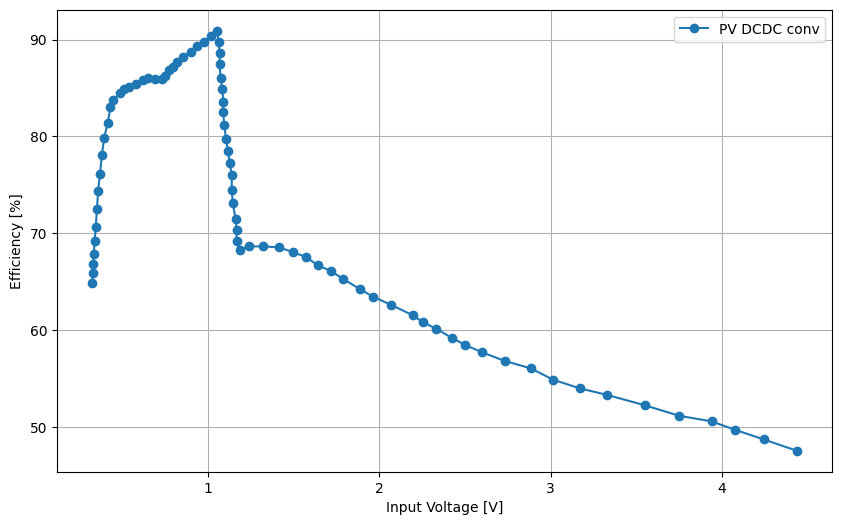

#define SIZE_CONV_PV 78
static const double V_CONV_PV[SIZE_CONV_PV] = {0.322, 0.325, 0.327, 0.332, 0.336, 0.343, 0.350, 0.357, 0.368, 0.379, 0.392, 0.412, 0.429, 0.446, 0.483, 0.507, 0.536, 0.580, 0.622, 0.650, 0.686, 0.732, 0.747, 0.773, 0.796, 0.820, 0.853, 0.897, 0.933, 0.975, 1.015, 1.051, 1.061, 1.066, 1.066, 1.072, 1.082, 1.088, 1.088, 1.093, 1.104, 1.115, 1.126, 1.137, 1.137, 1.143, 1.160, 1.166, 1.166, 1.183, 1.237, 1.319, 1.414, 1.493, 1.569, 1.640, 1.715, 1.784, 1.884, 1.960, 2.070, 2.197, 2.252, 2.331, 2.425, 2.498, 2.599, 2.731, 2.884, 3.016, 3.169, 3.329, 3.551, 3.749, 3.940, 4.079, 4.243, 4.437};
static const double ETA_CONV_PV[SIZE_CONV_PV] = {64.82, 65.90, 66.78, 67.85, 69.22, 70.68, 72.54, 74.40, 76.16, 78.11, 79.87, 81.34, 83.00, 83.78, 84.46, 84.85, 85.15, 85.44, 85.83, 86.03, 85.93, 85.93, 86.22, 86.81, 87.20, 87.69, 88.18, 88.76, 89.35, 89.74, 90.33, 90.91, 89.74, 88.57, 87.49, 86.03, 84.85, 83.58, 82.51, 81.14, 79.77, 78.50, 77.23, 75.96, 74.50, 73.13, 71.47, 70.2

In [24]:
# PV Panel Converter
# Extract digitalized points
data = np.loadtxt('datasheet/PV_DCDCconv/trace_3V_10mA_2.2V.txt', delimiter=',', skiprows=1)
voltage = data[:, 0]
eta = data[:, 1]



# Plot
plt.figure(figsize=(10, 6))
plt.plot(voltage, eta, 'o-', label='PV DCDC conv')
plt.ylabel('Efficiency [%]')
plt.xlabel('Input Voltage [V]')
plt.legend()
plt.grid(True)
plt.show()

# Generazione stringhe per il file .h
v_str = ", ".join([f"{v:.3f}" for v in voltage])
eta_str = ", ".join([f"{e:.2f}" for e in eta])

print(f"#define SIZE_CONV_PV {len(voltage)}")
print(f"static const double V_CONV_PV[SIZE_CONV_PV] = {{{v_str}}};")
print(f"static const double ETA_CONV_PV[SIZE_CONV_PV] = {{{eta_str}}};")


![](datasheet/Battery_DCDCconv/dcdc_fig.jpg)

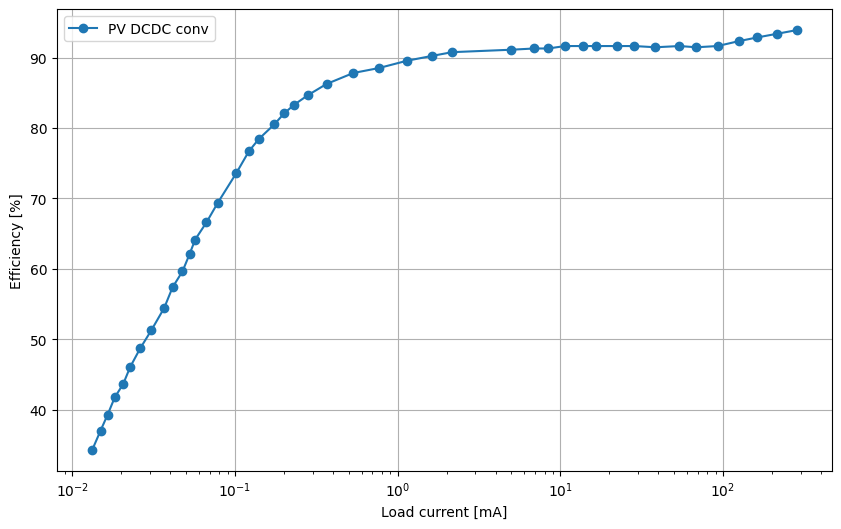

#define SIZE_CONV_PV 44
static const double I_CONV_BATT[SIZE_CONV_PV] = {0.013, 0.015, 0.016, 0.018, 0.021, 0.023, 0.026, 0.031, 0.037, 0.041, 0.048, 0.053, 0.057, 0.067, 0.078, 0.102, 0.122, 0.140, 0.174, 0.200, 0.231, 0.282, 0.365, 0.534, 0.765, 1.141, 1.635, 2.163, 5.008, 6.895, 8.421, 10.703, 13.879, 16.614, 22.423, 28.501, 38.465, 54.030, 68.676, 92.686, 125.090, 162.207, 214.584, 283.873};
static const double ETA_CONV_BATT[SIZE_CONV_PV] = {34.26, 37.04, 39.30, 41.74, 43.65, 46.09, 48.70, 51.30, 54.43, 57.39, 59.65, 62.09, 64.17, 66.61, 69.39, 73.57, 76.70, 78.43, 80.52, 82.09, 83.30, 84.70, 86.26, 87.83, 88.52, 89.57, 90.26, 90.78, 91.13, 91.30, 91.30, 91.65, 91.65, 91.65, 91.65, 91.65, 91.48, 91.65, 91.48, 91.65, 92.35, 92.87, 93.39, 93.91};


In [25]:
# Battery Converter
# Extract digitalized points
data = np.loadtxt('datasheet/Battery_DCDCconv/trace_2.4V_log10.txt', delimiter=',', skiprows=1)
current = data[:, 0]
current = current[::-1]
eta = data[:, 1]
eta = eta[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(current, eta, 'o-', label='PV DCDC conv')
plt.ylabel('Efficiency [%]')
plt.xscale('log') # Set x-axis to log scale
plt.xlabel('Load current [mA]')
plt.legend()
plt.grid(True)
plt.show()

# Generazione stringhe per il file .h
c_str = ", ".join([f"{c:.3f}" for c in current])
eta_str = ", ".join([f"{e:.2f}" for e in eta])

print(f"#define SIZE_CONV_PV {len(current)}")
print(f"static const double I_CONV_BATT[SIZE_CONV_PV] = {{{c_str}}};")
print(f"static const double ETA_CONV_BATT[SIZE_CONV_PV] = {{{eta_str}}};")


# Battery model

![](datasheet/Battery/datasheet.jpg)

In [26]:
from scipy.interpolate import interp1d

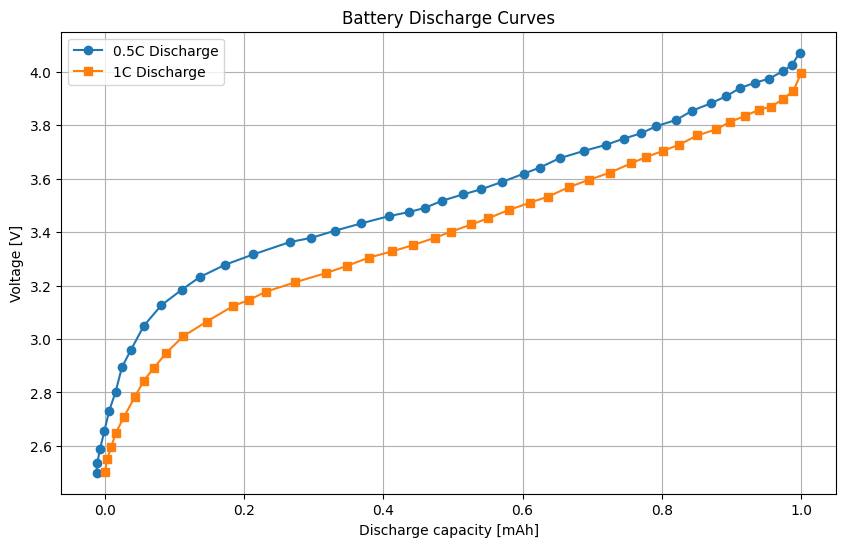

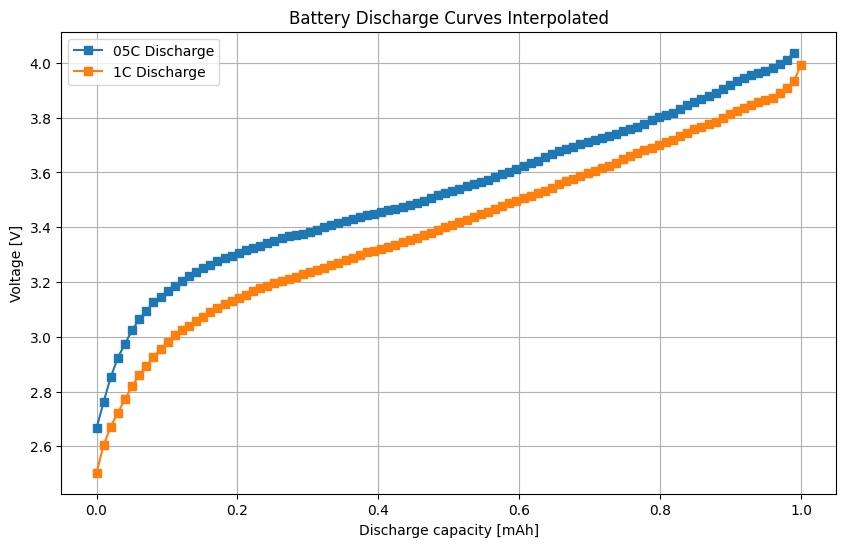

In [27]:
# Extract digitalized points for 0.5C
data05 = np.loadtxt('datasheet/Battery/trace_05C.txt', delimiter=',', skiprows=1)
voltage05 = data05[:, 0]
discharge05 = data05[:, 1]

# Extract digitalized points for 1C
data1 = np.loadtxt('datasheet/Battery/trace_1C.txt', delimiter=',', skiprows=1)
voltage1 = data1[:, 0]
discharge1 = data1[:, 1]

# Plotting
plt.figure(figsize=(10, 6))

# Plot the first curve (0.5C)
# Note: switched order to (discharge, voltage) to match your labels
plt.plot(voltage05, discharge05, 'o-', label='0.5C Discharge')

# Plot the second curve (1C) on the same axes
plt.plot(voltage1, discharge1, 's-', label='1C Discharge')

# Formatting
plt.xlabel('Discharge capacity [mAh]')
plt.ylabel('Voltage [V]')
plt.title('Battery Discharge Curves')
plt.legend()
plt.grid(True)

plt.show()

# Plotting
plt.figure(figsize=(10, 6))

# Interpolate
interp_func05 = interp1d(voltage05, discharge05, bounds_error=False)
newX05 = np.linspace(0, 1, 100)
newY05 = interp_func05(newX05)
plt.plot(newX05, newY05, 's-', label='05C Discharge')

# Interpolate
interp_func1 = interp1d(voltage1, discharge1, bounds_error=False)
newX1 = np.linspace(0, 1, 100)
newY1 = interp_func1(newX1)
plt.plot(newX1, newY1, 's-', label='1C Discharge')

# Formatting
plt.xlabel('Discharge capacity [mAh]')
plt.ylabel('Voltage [V]')
plt.title('Battery Discharge Curves Interpolated')
plt.legend()
plt.grid(True)

plt.show()



In [28]:
# Now we have the two curves with the same X space
nomimal_capacity = 3200/100     # Ah
interp_func05 = interp1d(voltage05, discharge05, bounds_error=False)
interp_func1 = interp1d(voltage1, discharge1, bounds_error=False)

soc_Curve = np.linspace(0, 1, 100)

V_curve05 = interp_func05(soc_Curve)
V_curve1 = interp_func1(soc_Curve)

I1 = 1*nomimal_capacity
I05 = 0.5*nomimal_capacity


R = (V_curve05-V_curve1)/(I1-I05)
Voc = V_curve1 + R * I1

# Remove ana 
mask = ~np.isnan(Voc) & ~np.isnan(R)
x_fit = soc_Curve[mask]
y_voc = Voc[mask]
y_r = R[mask]

### How to use `curve_fit`

In [29]:
from scipy.optimize import curve_fit

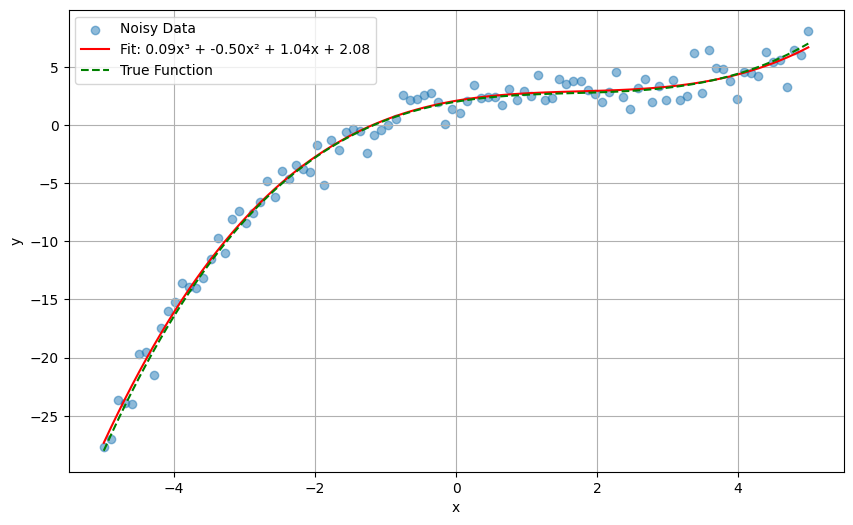

In [30]:
# Define polynomial function (3rd degree)
def poly_func(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

# Generate data
x_data = np.linspace(-5, 5, 100)
true_params = [0.1, -0.5, 1.0, 2.0]  # True coefficients
y_true = poly_func(x_data, *true_params)
noise = np.random.normal(0, 1, len(x_data))
y_data = y_true + noise

# Fit the data
popt, pcov = curve_fit(poly_func, x_data, y_data)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.5, label='Noisy Data')
plt.plot(x_data, poly_func(x_data, *popt), 'r-', 
         label=f'Fit: {popt[0]:.2f}x³ + {popt[1]:.2f}x² + {popt[2]:.2f}x + {popt[3]:.2f}')
plt.plot(x_data, y_true, 'g--', label='True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

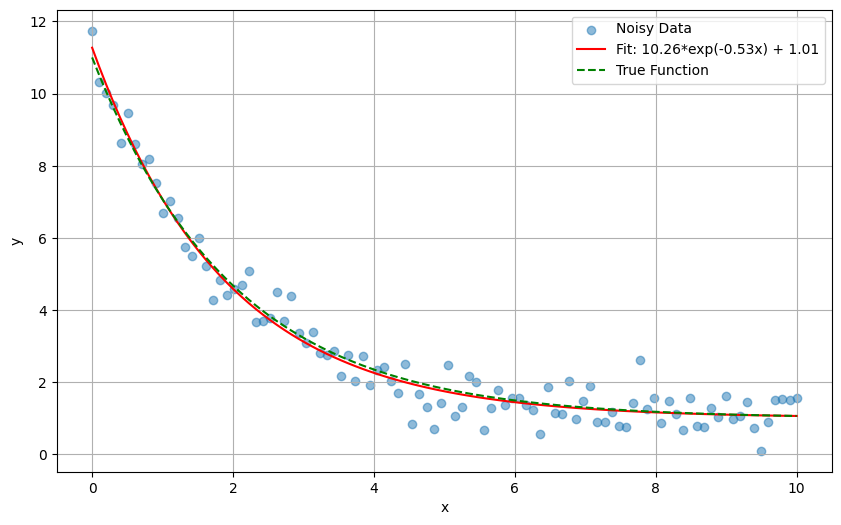

In [31]:
# Define exponential decay function
def exp_decay(x, A, k, c):
    return A * np.exp(-k * x) + c

# Generate data
x_data = np.linspace(0, 10, 100)
true_params = [10.0, 0.5, 1.0]  # [amplitude, decay rate, offset]
y_true = exp_decay(x_data, *true_params)
noise = np.random.normal(0, 0.5, len(x_data))
y_data = y_true + noise

# Fit the data
popt, pcov = curve_fit(exp_decay, x_data, y_data)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.5, label='Noisy Data')
plt.plot(x_data, exp_decay(x_data, *popt), 'r-', 
         label=f'Fit: {popt[0]:.2f}*exp(-{popt[1]:.2f}x) + {popt[2]:.2f}')
plt.plot(x_data, y_true, 'g--', label='True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### Overfitting Example

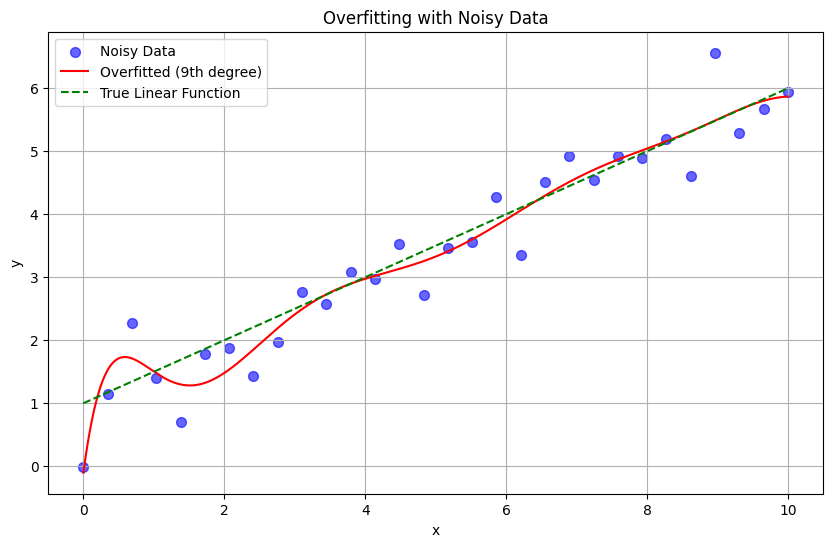

In [32]:
# Define high degree polynomial for overfitting
def complex_func(x, a0, a1, a2, a3, a4, a5, a6, a7, a8, a9):
    return (a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4 + 
            a5*x**5 + a6*x**6 + a7*x**7 + a8*x**8 + a9*x**9)

# Generate more points with higher noise
x_data = np.linspace(0, 10, 30)  # Increased to 30 points
true_params = [1.0, 0.5]
y_true = true_params[0] + true_params[1] * x_data
noise = np.random.normal(0, 0.5, len(x_data))  # Increased noise standard deviation to 0.5
y_data = y_true + noise

# Fit with overly complex function
initial_guess = np.ones(10)
popt, pcov = curve_fit(complex_func, x_data, y_data, p0=initial_guess)

# Generate smooth points for plotting
x_smooth = np.linspace(0, 10, 1000)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='blue', s=50, alpha=0.6, label='Noisy Data')
plt.plot(x_smooth, complex_func(x_smooth, *popt), 'r-', 
         label='Overfitted (9th degree)')
plt.plot(x_smooth, true_params[0] + true_params[1]*x_smooth, 'g--',
         label='True Linear Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Overfitting with Noisy Data')
plt.grid(True)
plt.show()

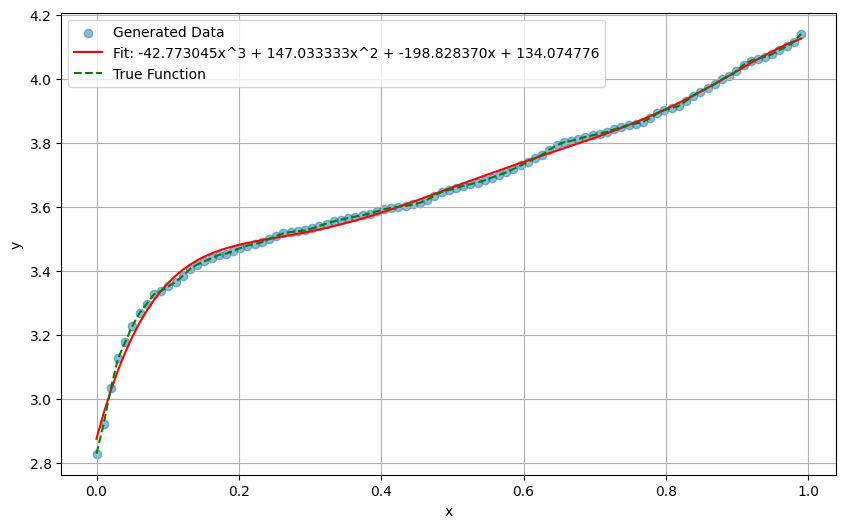

np.float64(3.739594676401317)

In [33]:
# Fit the data to obtain V_OC(SOC)
# Define polynomial function (3rd degree)
def model_voc(x, a, b, c, d, e, f, g):
    return a*x**6 + b*x**5 + c*x**4 + d*x**3 + e*x**2 + f*x + g
 
# Fit the data
popt, _ = curve_fit(model_voc, x_fit, y_voc)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x_fit, y_voc, alpha=0.5, label='Generated Data')
plt.plot(x_fit, model_voc(x_fit, *popt), 'r-',
         label = f'Fit: {popt[0]:.6f}x^3 + {popt[1]:.6f}x^2 + {popt[2]:.6f}x + {popt[3]:.6f}')
plt.plot(x_fit, y_voc, 'g--', label='True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

def get_voc(soc):
    return model_voc(soc, *popt)

get_voc(0.6)

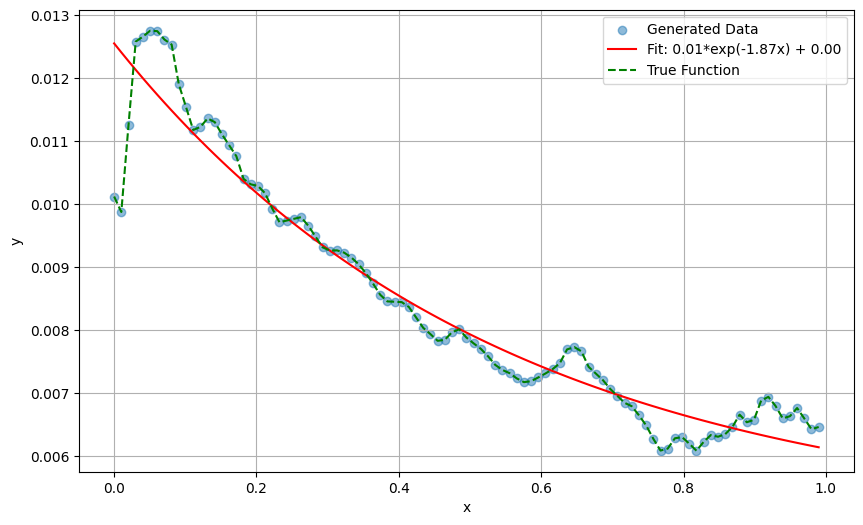

np.float64(0.007420338237264864)

In [34]:
# Fit the data to obtain R(SOC)
# R

# Define exponential decay function
def model_r(x, A, k, c):
    return A * np.exp(-k * x) + c

# Fit R 
popt, _ = curve_fit(model_r, x_fit, y_r)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x_fit, y_r, alpha=0.5, label='Generated Data')
plt.plot(x_fit, model_r(x_fit, *popt), 'r-', 
         label=f'Fit: {popt[0]:.2f}*exp(-{popt[1]:.2f}x) + {popt[2]:.2f}')
plt.plot(x_fit, y_r, 'g--', label='True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

def get_R(soc):
    return model_r(soc, *popt)

get_R(0.6)